## Data project

## Opgave 1.1

               ULLIG    KOMMUNEDK   TID  INDHOLD
0   Gini-koefficient  Hele landet  1987    22.07
1   Gini-koefficient  Hele landet  1988    22.06
2   Gini-koefficient  Hele landet  1989    21.93
3   Gini-koefficient  Hele landet  1990    22.16
4   Gini-koefficient  Hele landet  1991    21.99
5   Gini-koefficient  Hele landet  1992    22.34
6   Gini-koefficient  Hele landet  1993    22.79
7   Gini-koefficient  Hele landet  1994    22.50
8   Gini-koefficient  Hele landet  1995    22.41
9   Gini-koefficient  Hele landet  1996    22.83
10  Gini-koefficient  Hele landet  1997    23.47
11  Gini-koefficient  Hele landet  1998    23.81
12  Gini-koefficient  Hele landet  1999    23.83
13  Gini-koefficient  Hele landet  2000    24.38
14  Gini-koefficient  Hele landet  2001    24.40
15  Gini-koefficient  Hele landet  2002    24.03
16  Gini-koefficient  Hele landet  2003    24.14
17  Gini-koefficient  Hele landet  2004    24.68
18  Gini-koefficient  Hele landet  2005    25.66
19  Gini-koefficient

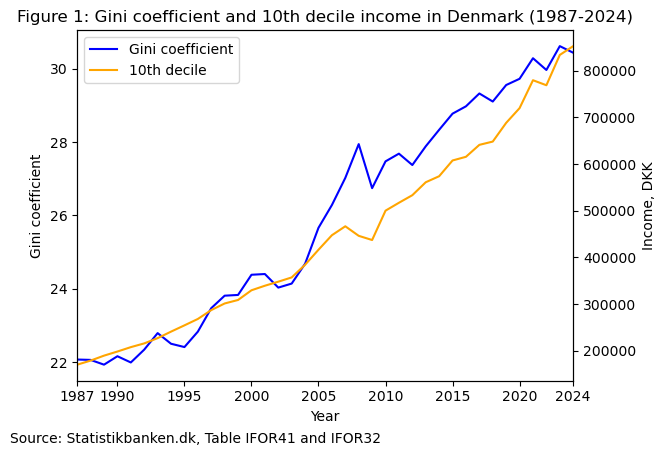

In [67]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# We import the data from Statistics Denmark's API. The data is about the Gini coefficient in Denmark, which measures income inequality.

url = "https://api.statbank.dk/v1/data"

query = {
    "table": "IFOR41",
   "format": "CSV",
   "variables": [
      {
         "code": "ULLIG",
         "placement": "Stub",
         "values": [
            "70"
         ]
      },
      {
         "code": "KOMMUNEDK",
         "placement": "Stub",
         "values": [
            "000"
         ]
      },
      {
         "code": "Tid",
         "placement": "Stub",
         "values": [
            "*"
         ]
      }
   ]
}

reponse = requests.post(url, json=query)

df = pd.read_csv(
    StringIO(reponse.text),
    sep=";",
    decimal=",",
)

url = "https://api.statbank.dk/v1/data"

query2 = {
    "table": "IFOR32",
   "format": "CSV",
   "variables": [
      {
         "code": "DECILGEN",
         "placement": "Stub",
         "values": [
            "10DC"
         ]
      },
      {
         "code": "KOMMUNEDK",
         "values": [
            "000"
         ]
      },
      {
         "code": "Tid",
         "values": [
            "*"
         ]
      }
   ]
}

response2 = requests.post(url, json=query2)

df2 = pd.read_csv(
    StringIO(response2.text),
    sep=";",
    decimal=","
)

print(df)
print(df2)

fig, ax1 = plt.subplots()

# Første y-akse: df
ax1.plot(
    df["TID"],
    df["INDHOLD"],
    label="Gini coefficient",
    color = "blue"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient")


# Anden y-akse: df2
ax2 = ax1.twinx()

ax2.plot(
    df2["TID"],
    df2["INDHOLD"],
    label="10th decile",
    color = "orange"
)

ax2.set_ylabel("Income, DKK")


# Titel
plt.title("Figure 1: Gini coefficient and 10th decile income in Denmark (1987-2024)")


# X-akse
ax1.set_xlim(
    min(df["TID"].min(), df2["TID"].min()),
    max(df["TID"].max(), df2["TID"].max())
)

ax1.set_xticks([1987, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024])



# Kilde
plt.subplots_adjust(bottom=0.15)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41 and IFOR32",
    ha="left"
)

# Vis både kurvelabels i legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.show()



ghg


## Opgave 1.2

Linear coefficients from minimize:
[21.04275354  0.26354959]

Quadratic coefficients from minimize:
[2.13041883e+01 2.19976116e-01 1.17766330e-03]

Linear coefficients:
Minimize: [21.04275354  0.26354959]
Polyfit:  [21.04275304  0.26354962]

Quadratic coefficients:
Minimize: [2.13041883e+01 2.19976116e-01 1.17766330e-03]
Polyfit:  [2.13042004e+01 2.19975061e-01 1.17769085e-03]

Predictions:
Linear prediction 2030: 32.38
Linear prediction 2040: 35.01
Quadratic prediction 2030: 32.94
Quadratic prediction 2040: 36.27


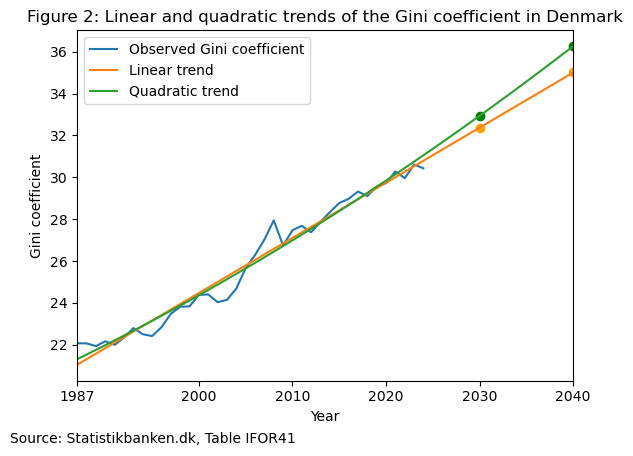

In [68]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# --------------------------------------------------
# 1. Prepare the data
# --------------------------------------------------

# Gini coefficient
y = df["INDHOLD"].to_numpy()

# t = number of years since 1987
t = df["TID"].to_numpy() - 1987


# --------------------------------------------------
# 2. Linear trend using scipy.optimize.minimize
# --------------------------------------------------

def objective_linear(beta):
    beta0, beta1 = beta

    y_hat = beta0 + beta1 * t

    return np.sum((y - y_hat) ** 2)


# Initial values
beta_start_linear = np.array([0, 0])

# Solve the minimization problem
result_linear = minimize(
    objective_linear,
    beta_start_linear
)

beta_linear = result_linear.x

print("Linear coefficients from minimize:")
print(beta_linear)


# --------------------------------------------------
# 3. Quadratic trend using scipy.optimize.minimize
# --------------------------------------------------

def objective_quadratic(beta):
    beta0, beta1, beta2 = beta

    y_hat = beta0 + beta1 * t + beta2 * t**2

    return np.sum((y - y_hat) ** 2)


# Initial values
beta_start_quadratic = np.array([0, 0, 0])

# Solve the minimization problem
result_quadratic = minimize(
    objective_quadratic,
    beta_start_quadratic
)

beta_quadratic = result_quadratic.x

print("\nQuadratic coefficients from minimize:")
print(beta_quadratic)


# --------------------------------------------------
# 4. Check the results using np.polyfit
# --------------------------------------------------

polyfit_linear = np.polyfit(t, y, 1)
polyfit_quadratic = np.polyfit(t, y, 2)

print("\nLinear coefficients:")
print("Minimize:", beta_linear)
print("Polyfit: ", polyfit_linear[::-1])

print("\nQuadratic coefficients:")
print("Minimize:", beta_quadratic)
print("Polyfit: ", polyfit_quadratic[::-1])


# --------------------------------------------------
# 5. Predictions for 2030 and 2040
# --------------------------------------------------

t_2030 = 2030 - 1987
t_2040 = 2040 - 1987


# Linear predictions
gini_linear_2030 = (
    beta_linear[0]
    + beta_linear[1] * t_2030
)

gini_linear_2040 = (
    beta_linear[0]
    + beta_linear[1] * t_2040
)


# Quadratic predictions
gini_quadratic_2030 = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2030
    + beta_quadratic[2] * t_2030**2
)

gini_quadratic_2040 = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2040
    + beta_quadratic[2] * t_2040**2
)


print("\nPredictions:")

print(
    "Linear prediction 2030:",
    round(gini_linear_2030, 2)
)

print(
    "Linear prediction 2040:",
    round(gini_linear_2040, 2)
)

print(
    "Quadratic prediction 2030:",
    round(gini_quadratic_2030, 2)
)

print(
    "Quadratic prediction 2040:",
    round(gini_quadratic_2040, 2)
)


# --------------------------------------------------
# 6. Create fitted and predicted values for the plot
# --------------------------------------------------

# Years from 1987 to 2040
years_plot = np.arange(1987, 2041)

# Convert years to t
t_plot = years_plot - 1987


# Linear trend
gini_linear = (
    beta_linear[0]
    + beta_linear[1] * t_plot
)


# Quadratic trend
gini_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)


# --------------------------------------------------
# 7. Plot historical data and predictions
# --------------------------------------------------

plt.plot(
    df["TID"],
    df["INDHOLD"],
    label="Observed Gini coefficient"
)

plt.plot(
    years_plot,
    gini_linear,
    label="Linear trend"
)

plt.plot(
    years_plot,
    gini_quadratic,
    label="Quadratic trend"
)


# Mark predictions for 2030 and 2040
plt.scatter(
    [2030, 2040],
    [gini_linear_2030, gini_linear_2040],
    color = "orange"
)

plt.scatter(
    [2030, 2040],
    [gini_quadratic_2030, gini_quadratic_2040],
    color = "green"
)


plt.xlabel("Year")
plt.ylabel("Gini coefficient")

plt.title(
    "Figure 2: Linear and quadratic trends of the Gini coefficient in Denmark"
)

plt.xticks(
    [1987, 2000, 2010, 2020, 2030, 2040]
)

plt.xlim(1987, 2040)

plt.legend()

plt.subplots_adjust(bottom=0.15)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41",
    ha="left"
)

plt.show()

## OPGAVE 1.3

In [69]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

url = "https://api.statbank.dk/v1/data"

query3 = {
   "table": "IFOR32",
   "format": "CSV",
   "variables": [
      {
         "code": "DECILGEN",
         "placement": "Stub",
         "values": [
            "10DC"
         ]
      },
      {
         "code": "KOMMUNEDK",
         "values": [
            "*"
         ]
      },
      {
         "code": "Tid",
         "values": [
            "*"
         ]
      }
   ]
}

response3 = requests.post(url, json=query3)

df3 = pd.read_csv(StringIO(response3.text),sep=";",decimal=",")

#Remove "Hele landet"

df3 = df3[df3["KOMMUNEDK"] != "Hele landet"].copy()

print(df3)


       DECILGEN  KOMMUNEDK   TID  INDHOLD
38    10. decil  København  1987   155794
39    10. decil  København  1988   163769
40    10. decil  København  1989   170177
41    10. decil  København  1990   177753
42    10. decil  København  1991   182779
...         ...        ...   ...      ...
3757  10. decil    Aalborg  2020   631707
3758  10. decil    Aalborg  2021   664032
3759  10. decil    Aalborg  2022   675088
3760  10. decil    Aalborg  2023   698292
3761  10. decil    Aalborg  2024   730961

[3724 rows x 4 columns]


## OPGAVE 2.1/2.2 (OPGAVE 2.1 is in the file life_cycle_model.py)

In [84]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import importlib.util
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Locate the life_cycle_model.py file
file_path = os.path.abspath("life_cycle_model.py")
if not os.path.exists(file_path):
    file_path = os.path.abspath(
        os.path.join("Data project", "life_cycle_model.py")
    )

# 2. Importing the module using importlib
spec = importlib.util.spec_from_file_location("life_cycle_model", file_path)
life_cycle_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(life_cycle_model)

# 3. Withdraw the function and run the simulation
simulate_lifecycle = life_cycle_model.simulate_lifecycle
sim = simulate_lifecycle(seed=23, N=50000)

print()

=== 1. SANITY CHECKS ===
Simulating education distribution: Short=0.4040, Medium=0.3471, Long=0.2489
Theoretical p_e:                 Short=0.4000, Medium=0.3500, Long=0.2500
Simulated unemployment rate (age 43): 0.0746 (7.46%)
Theoretical steady-state unemployment:   0.0769 (7.69%)



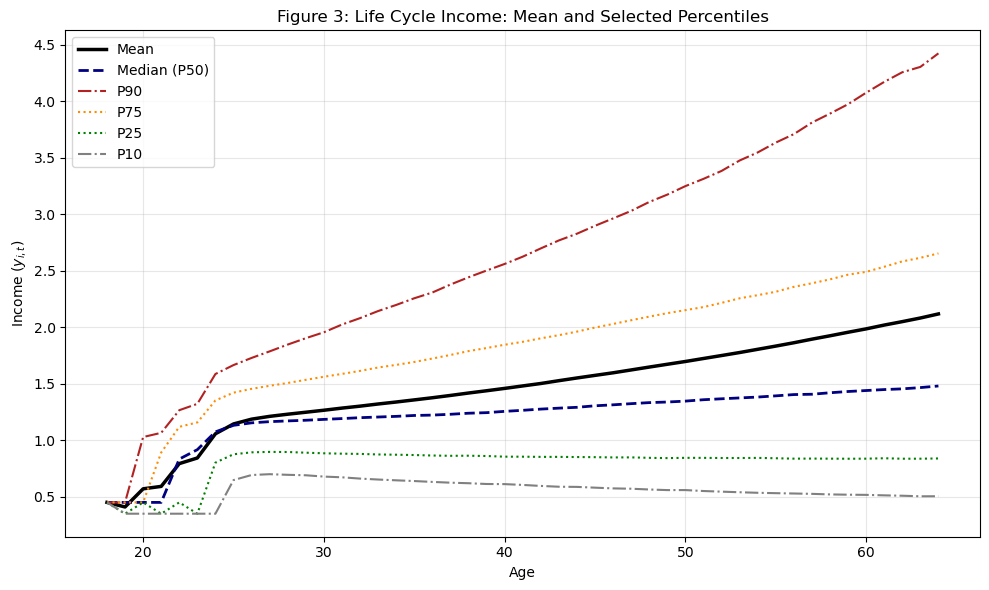

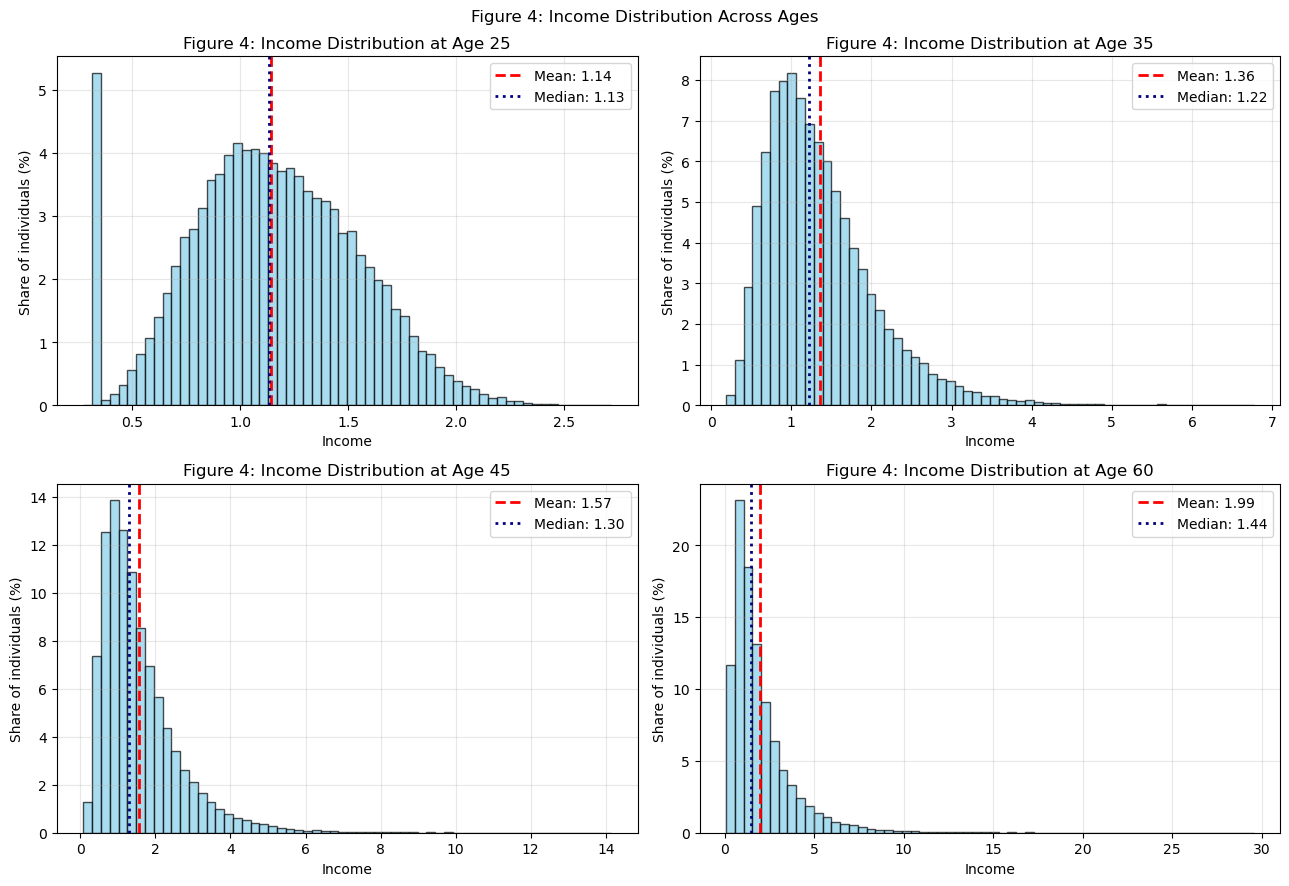

In [72]:
# Unpacking the simulated data
income = sim["income"]
employed = sim["employed"]
edu_idx = sim["edu_idx"]
p_e = sim["p_e"]
sigma_p = sim["sigma_p"]
lambda_p = sim["lambda_p"]

# =============================================================================
# Point 1: Model Checks (Sanity Checks)
# =============================================================================
print("=== 1. SANITY CHECKS ===")

# Check Education shares: Simulated vs. theoretical
sim_p_e = [np.mean(edu_idx == i) for i in range(3)]
print(
    f"Simulating education distribution: Short={sim_p_e[0]:.4f}, Medium={sim_p_e[1]:.4f}, Long={sim_p_e[2]:.4f}"
)
print(
    f"Theoretical p_e:                 Short={p_e[0]:.4f}, Medium={p_e[1]:.4f}, Long={p_e[2]:.4f}"
)

# Check b: employmentrate in steady-state (after all is educated, ex. t=25 / age 43)
unemployment_rate_by_age = 1 - np.mean(employed, axis=0)
sim_ss_unemp = unemployment_rate_by_age[25]
theoretical_ss_unemp = sigma_p / (sigma_p + lambda_p)

print(
    f"Simulated unemployment rate (age 43): {sim_ss_unemp:.4f} ({sim_ss_unemp*100:.2f}%)"
)
print(
    f"Theoretical steady-state unemployment:   {theoretical_ss_unemp:.4f} ({theoretical_ss_unemp*100:.2f}%)\n"
)


# =============================================================================
# Point 2: Plot mean and selected percentiles over the life cycle
# =============================================================================
ages = np.arange(18, 65)

# Calculate mean and percentiles over the life cycle
mean_inc = np.mean(income, axis=0)
p10 = np.percentile(income, 10, axis=0)
p25 = np.percentile(income, 25, axis=0)
p50 = np.percentile(income, 50, axis=0)
p75 = np.percentile(income, 75, axis=0)
p90 = np.percentile(income, 90, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(ages, mean_inc, label="Mean", color="black", lw=2.5)
plt.plot(
    ages, p50, label="Median (P50)", color="navy", lw=2, linestyle="--"
)
plt.plot(ages, p90, label="P90", color="firebrick", lw=1.5, linestyle="-.")
plt.plot(ages, p75, label="P75", color="darkorange", lw=1.5, linestyle=":")
plt.plot(ages, p25, label="P25", color="green", lw=1.5, linestyle=":")
plt.plot(ages, p10, label="P10", color="gray", lw=1.5, linestyle="-.")

plt.title("Figure 3: Life Cycle Income: Mean and Selected Percentiles", fontsize=12)
plt.xlabel("Age")
plt.ylabel("Income ($y_{i,t}$)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =============================================================================
# Point- 3: Plot histograms of income distribution at ages 25, 35, 45, and 60
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, age in enumerate([25, 35, 45, 60]):
    t_idx = age - 18  # t_idx=0 equals to the age 18
    inc_age = income[:, t_idx]
    weights = np.ones(len(inc_age), dtype=float) / len(inc_age) * 100

    axes[i].hist(
        inc_age,
        bins=60,
        weights=weights,
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    axes[i].axvline(
        np.mean(inc_age),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {np.mean(inc_age):.2f}",
    )
    axes[i].axvline(
        np.median(inc_age),
        color="navy",
        linestyle=":",
        linewidth=2,
        label=f"Median: {np.median(inc_age):.2f}",
    )

    axes[i].set_title(f"Figure 4: Income Distribution at Age {age}")
    axes[i].set_xlabel("Income")
    axes[i].set_ylabel("Share of individuals (%)")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Figure 4: Income Distribution Across Ages", y=0.98)
plt.tight_layout()
plt.show()

# 2.1 Figure description 
FIGURE 3: 

This figure illustrates that income differences become larger over the life cycle. Although individuals begin from a similar starting point, the model generates increasingly different income paths over time, with high-income groups rising strongly and low-income groups remaining much lower. This pattern suggests that inequality rises with age.


FIGURE 4: 

This figure shows the income distribution at ages 25, 35, 45, and 60. At age 25, a relatively large share of individuals are still concentrated around the lower-income level, which likely reflects people who have not yet found a job after completing education or who are still in the early stages of the labor market. As age increases, the distribution becomes more spread out and more right-skewed, meaning that a smaller group of individuals earn much higher incomes than the typical person. This is reflected in the fact that the mean becomes increasingly larger than the median over time, which suggests that a few very high-income observations pull the average upward. This pattern supports the conclusion that inequality rises over the life cycle, in line with Figure 3, where the gap between lower- and higher-income individuals becomes larger over time.

## 2.3 GINI

In [73]:
import numpy as np
import matplotlib.pyplot as plt


def gini(x):
    x = np.asarray(x).flatten() # Ensure x is a 1D array
    x_sorted = np.sort(x, axis=0)
    n = len(x_sorted)

    i = np.arange(1,n + 1)

    gini_coefficient = (2 * np.sum(i * x_sorted)) / (n * np.sum(x_sorted)) - (n + 1) / n
    return gini_coefficient

#Test
x_test = rng_test.uniform(0, 1, size=1000000)

print(gini(x_test))

std = np.std(x_test)
print(f"Standard deviation of the test data: {std:.4f}")

0.3333139346632419
Standard deviation of the test data: 0.2887


In [74]:
#Calculate Gini coefficient for the simulated income data
print(gini(income))

0.3733180288675684


Above states the gini coefficient for the data set over the period. Number 0 means zero inequality 10 % of the people earn 10 % of the total income. Where 1.00 means big inequality where one person holds all the income.

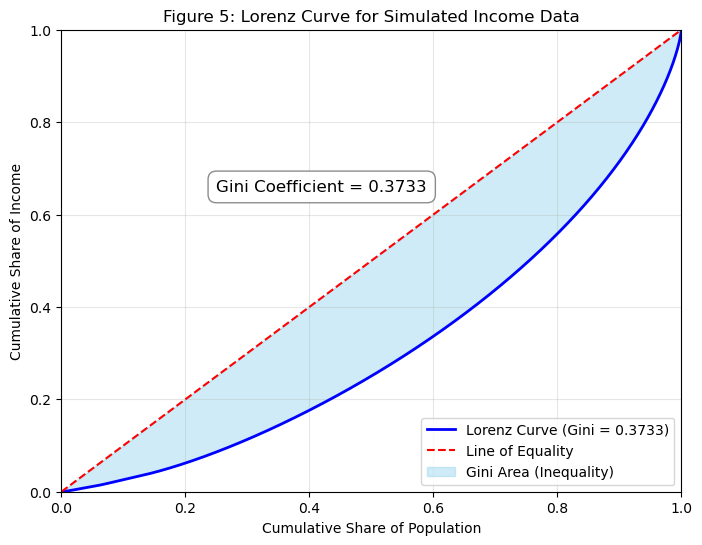

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the Lorenz curve and Gini coefficient
population_share, income_share = lorenz_curve(income)
gini_val = gini(income)

plt.figure(figsize=(8, 6))

# 2. Curve and line of equality
plt.plot(
    population_share,
    income_share,
    label=f"Lorenz Curve (Gini = {gini_val:.4f})",
    color="blue",
    linewidth=2,
)
plt.plot(
    [0, 1], [0, 1], label="Line of Equality", color="red", linestyle="--"
)

# 3. Mark the area that represents the Gini coefficient 
plt.fill_between(
    population_share,
    population_share,
    income_share,
    color="skyblue",
    alpha=0.4,
    label="Gini Area (Inequality)",
)

# 4. Textbox with the values
plt.text(
    0.25,
    0.65,
    f"Gini Coefficient = {gini_val:.4f}",
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9
    ),
)

plt.title("Figure 5: Lorenz Curve for Simulated Income Data")
plt.xlabel("Cumulative Share of Population")
plt.ylabel("Cumulative Share of Income")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

Figure 5: visualises the gini coefficient. the blue area repsents the inequality, the greater area the more unequal. 

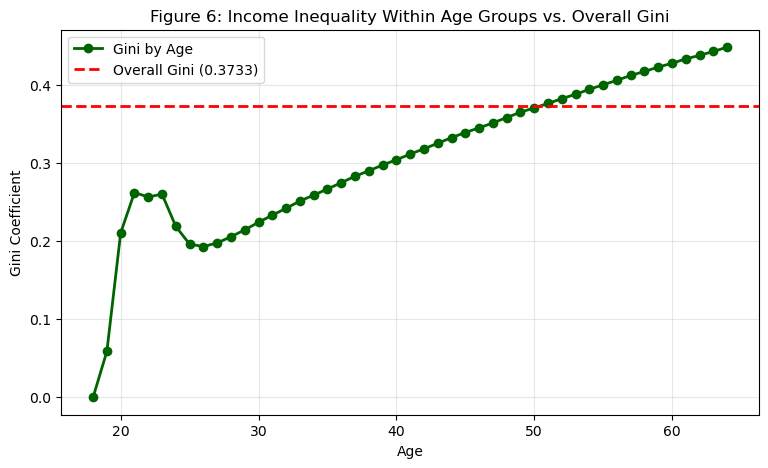

In [76]:
# Hent antallet af tidsperioder (aldre) fra income matrixen
T = income.shape[1]  # typisk 47 år (alder 18 til 64)
ages = np.arange(18, 18 + T)

# Beregn Gini for hver alder (kolonne t)
gini_by_age = [gini(income[:, t]) for t in range(T)] 

# 1. Beregn samlet Gini (pooled) og Gini pr. alder
gini_overall = gini(income)
gini_by_age = [gini(income[:, t]) for t in range(income.shape[1])]
ages = np.arange(18, 18 + income.shape[1])

# 2. Plot udviklingen i Gini over livscyklen
plt.figure(figsize=(9, 5))
plt.plot(
    ages,
    gini_by_age,
    marker="o",
    color="darkgreen",
    linewidth=2,
    label="Gini by Age",
)
plt.axhline(
    gini_overall,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Gini ({gini_overall:.4f})",
)

plt.title("Figure 6: Income Inequality Within Age Groups vs. Overall Gini")
plt.xlabel("Age")
plt.ylabel("Gini Coefficient")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Figure 6 shows the evolution of within age income inequality across the life cycle Initially between ages 18 and 23 the Gini coefficient rises sharply due to the divergence between students receiving student grants and individuals entering the labor market

Once education programs are completed the Gini coefficient drops as graduates transition into employment Subsequently inequality increases steadily for the remainder of the working life This long run rise in inequality is driven by differences in human capital growth rates across education levels the compounding effect of annual productivity shocks and human capital depreciation during unemployment spells By around age 50 within age inequality surpasses the overall Gini coefficient

# 2.4 What drives inequality

This section investigates the key drivers of income inequality within the life-cycle model. By systematically switching individual mechanisms on and off—specifically education differences, productivity shocks, human capital depreciation during unemployment, and unemployment risk itself—we isolate the marginal contribution of each component. Comparing these counterfactual scenarios against the baseline model allows us to determine which underlying parameter serves as the primary driver of overall inequality.

In [77]:
# 1. Definer alle scenarier
scenarios = {
    "Baseline": {},
    "1. No Educational Differences": {"no_edu_diff": True},
    "2. No Human Capital Shocks": {"no_shocks": True},
    "3. No Depreciation in Unemployment": {"no_depr": True},
    "4. No Unemployment": {"no_unemp": True},
}

results = []

# Choose a specific age group for the hint (e.g., age 50 -> index 50-18 = 32)
age_idx = 50 - 18

for name, kwargs in scenarios.items():
    sim = simulate_lifecycle(seed=23, N=50000, **kwargs)
    inc = sim["income"]

    gini_overall = gini(inc)
    gini_age_50 = gini(inc[:, age_idx])

    results.append(
        {
            "Scenario": name,
            "Overall Gini": round(gini_overall, 4),
            "Gini at Age 50": round(gini_age_50, 4),
        }
    )

# Vis som Pandas DataFrame / Tabel
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

                          Scenario  Overall Gini  Gini at Age 50
                          Baseline        0.3733          0.3704
     1. No Educational Differences        0.3203          0.3314
        2. No Human Capital Shocks        0.2769          0.2360
3. No Depreciation in Unemployment        0.3786          0.3589
                4. No Unemployment        0.3670          0.3574


Shocks to human capital is by far the most dominant driver of long-run income inequality, followed by educational differences. Unemployment dynamics play a comparatively minor role due to low equilibrium unemployment and the buffering effect of unemployment benefits.

From a policy perspective, while mitigating human capital shocks produces the largest reduction in inequality, directly eliminating these shocks is practically impossible due to their unpredictable, idiosyncratic nature (e.g., illness, sector-specific downturns, or technological shifts).

# 2.5

This section investigates how a 4-year macroeconomic recession affects income inequality and lifetime earnings when occurring early (ages 22–25), mid (ages 40–43), or late (ages 58–61) in the life cycle. During a recession, labor market conditions is effected as the job-finding probability drops from 60% to 30% and the layoff risk increases from 5% to 20%. By comparing these three scenarios against the baseline model, we examine how the timing of an economic shock effects employment dynamics, income accumulation, and inequality over time.

,Scenario,Mean Lifetime Income,Gini (Lifetime Income)
0,Baseline (No Recession),68.3355,0.2901
1,Early Recession (Age 22-25),61.9299,0.2961
2,Mid Recession (Age 40-43),64.3408,0.2864
3,Late Recession (Age 58-61),66.8635,0.2877


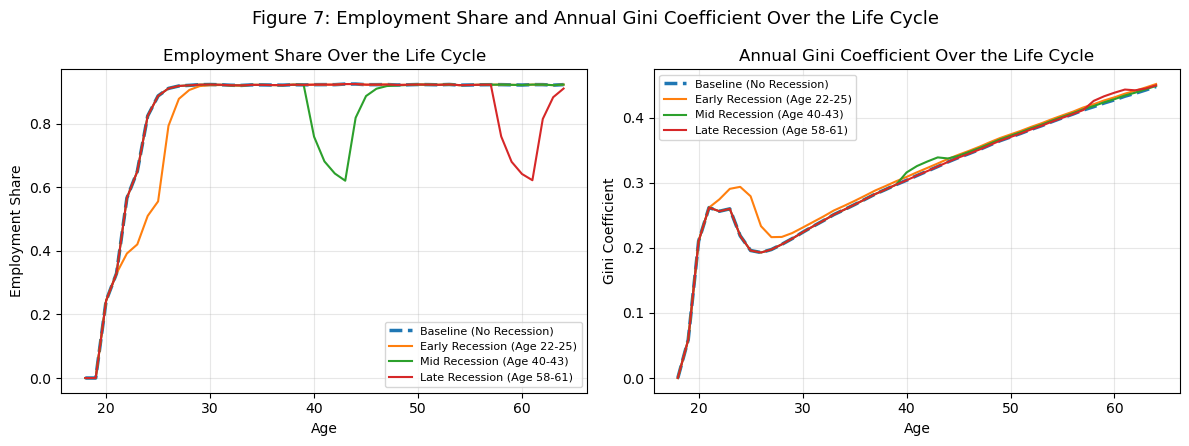

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from life_cycle_model import simulate_lifecycle


# 1. Helper function for recession scenarios
def run_recession_scenario(
    recession_years, recession_sigma_p=0.20, recession_lambda_p=0.30
):
    T = 65 - 18  # 47 years
    sigma_p_vec = np.full(T, 0.05)
    lambda_p_vec = np.full(T, 0.60)

    if recession_years is not None:
        for t in recession_years:
            sigma_p_vec[t] = recession_sigma_p
            lambda_p_vec[t] = recession_lambda_p

    return simulate_lifecycle(
        seed=23, N=50000, sigma_p=sigma_p_vec, lambda_p=lambda_p_vec
    )


# 2. Define scenarios and run simulations
scenarios = {
    "Baseline (No Recession)": None,
    "Early Recession (Age 22-25)": range(4, 8),
    "Mid Recession (Age 40-43)": range(22, 26),
    "Late Recession (Age 58-61)": range(40, 44),
}

results = {
    name: run_recession_scenario(years) for name, years in scenarios.items()
}


# 3. Gini function & Summary table
def calculate_gini(x):
    x = np.sort(x)
    n = len(x)
    return (
        float((np.sum((2 * np.arange(1, n + 1) - n - 1) * x)) / (n * np.sum(x)))
        if n > 0 and np.sum(x) > 0
        else 0.0
    )


summary_data = []
for name, res in results.items():
    lifetime_inc = np.sum(res["income"], axis=1)
    summary_data.append(
        {
            "Scenario": name,
            "Mean Lifetime Income": np.mean(lifetime_inc),
            "Gini (Lifetime Income)": calculate_gini(lifetime_inc),
        }
    )

display(pd.DataFrame(summary_data).round(4))


# 4. Plots (Figure 8: Employment and Annual Gini Dynamics)
ages = np.arange(18, 65)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(
    "Figure 7: Employment Share and Annual Gini Coefficient Over the Life"
    " Cycle",
    fontsize=13,
)

# Employment Share
for name, res in results.items():
    # Make Baseline dashed and thicker so it remains visible under other curves
    ls = "--" if "Baseline" in name else "-"
    lw = 2.5 if "Baseline" in name else 1.5
    ax1.plot(
        ages,
        np.mean(res["employed"], axis=0),
        label=name,
        linestyle=ls,
        linewidth=lw,
    )

ax1.set_title("Employment Share Over the Life Cycle")
ax1.set_xlabel("Age")
ax1.set_ylabel("Employment Share")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Annual Gini
for name, res in results.items():
    ls = "--" if "Baseline" in name else "-"
    lw = 2.5 if "Baseline" in name else 1.5
    gini_yr = [calculate_gini(res["income"][:, t]) for t in range(len(ages))]
    ax2.plot(ages, gini_yr, label=name, linestyle=ls, linewidth=lw)

ax2.set_title("Annual Gini Coefficient Over the Life Cycle")
ax2.set_xlabel("Age")
ax2.set_ylabel("Gini Coefficient")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Figure 7: The results show that a recession has a relatively small impact on overall lifetime inequality. However, when a recession occurs early in the career, lifetime Gini increases slightly from 0.2901 to 0.2961. This occurs because individuals who manage to stay employed or find a job despite the early shock gain a headstart, allowing them to accumulate human capital without interruption, which widens the income gap over time. Recessions occurring later in life have a negligible effect on lifetime inequality as workers have already established their human capital profiles. 

Finally, the lifetime Gini (~0.29) is lower than the cross-sectional Gini (~0.37) because they measure two different things. The cross-sectional Gini compares people of all ages at a single point in time, mixing low-earning young students with high-earning older workers. In contrast, the lifetime Gini tracks the same cohort over 47 years and sums their total earnings, which smooths out these temporary age-related income gaps.

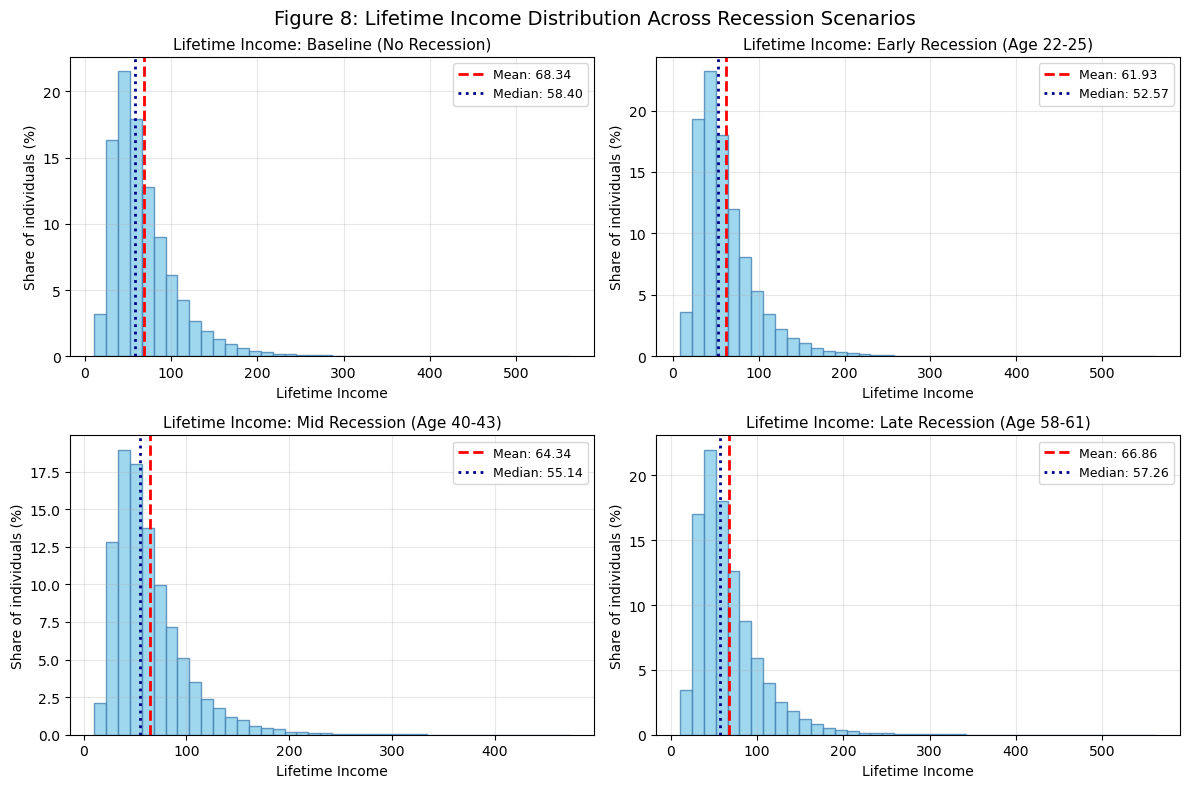

In [90]:
# -----------------------------------------------------------------------------
# 5. Histogram Plots: Lifetime Income Distribution Across Recession Scenarios
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    "Figure 8: Lifetime Income Distribution Across Recession Scenarios",
    fontsize=14,
)

# Flat array of axes for easy iteration
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]

    # Calculate total lifetime income for all individuals
    lifetime_inc = np.sum(res["income"], axis=1)

    mean_val = np.mean(lifetime_inc)
    median_val = np.median(lifetime_inc)

    # Plot histogram with exact styling matching Figure 4
    # (Light blue bars, dark blue edge, percentage on y-axis)
    weights = np.ones_like(lifetime_inc) / len(lifetime_inc) * 100
    ax.hist(
        lifetime_inc,
        bins=40,
        weights=weights,
        color="skyblue",
        edgecolor="steelblue",
        alpha=0.8,
    )

    # Vertical lines for Mean and Median
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_val:.2f}",
    )
    ax.axvline(
        median_val,
        color="darkblue",
        linestyle=":",
        linewidth=2,
        label=f"Median: {median_val:.2f}",
    )

    ax.set_title(f"Lifetime Income: {name}", fontsize=11)
    ax.set_xlabel("Lifetime Income")
    ax.set_ylabel("Share of individuals (%)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Adjust title space
plt.show()

Figure 8 showcases the lifetime income distribution across various scenarios. It demonstrates that whether a recession occurs in different decades or does not occur at all, it does not have a severe effect on overall inequality, as all the distributions remain right-skewed by approximately the same amount.

However, a recession that occurs early in the career has a significant negative effect on lifetime income accumulation. The reason for this is that an early recession harms the accumulation of human capital, which plays a crucial role in determining income in this model. Later in life, individuals have already built up their human capital stock, and they are therefore not affected as severely by the shock.